In [169]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline 

## Setting Paths

In [170]:
DATAPATH = "../data/"
DATAFILE_NAME = os.path.join(DATAPATH, "medical-appointments-no-show-en.csv")
ICD10FILE_NAME = os.path.join(DATAPATH, "icd10_2019.csv")

## 1. Loading the data into a df, collecting infos and preparing terrain

In [171]:
if os.path.exists(ICD10FILE_NAME):
    icd10 = pd.read_csv(ICD10FILE_NAME)
    icd10 = icd10[
        [
            "sub-code",
            "definition",
        ]
    ]
    display(
        icd10,
    )

,sub-code,definition
0,A00,Cholera
1,A00.0,"Cholera due to Vibrio cholerae 01, biovar chol..."
2,A00.1,"Cholera due to Vibrio cholerae 01, biovar eltor"
3,A00.9,"Cholera, unspecified"
4,A01,Typhoid and paratyphoid fevers
...,...,...
11238,U84.3,Resistance to tuberculostatic drug(s)
11239,U84.7,Resistance to multiple antimicrobial drugs
11240,U84.8,Resistance to other specified antimicrobial drug
11241,U84.9,Resistance to unspecified antimicrobial drugs


In [172]:
if os.path.exists(DATAFILE_NAME):
    data = pd.read_csv(DATAFILE_NAME)
    display(data)

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,NaN,motor,10/10/1954,5/2/2020,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,NaN,10:20,M,01/02/2022,yes,pai tem médico,intellectual,9/3/2009,5/11/2019,ITAJAÍ,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49589,NaN,10:20,M,01/02/2022,yes,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49590,NaN,11:00,M,01/02/2022,no,NaN,intellectual,7/3/2016,11/2/2020,BOMBINHAS,...,0,1,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49591,psychotherapy,11:00,M,01/02/2022,yes,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold


- Transforming the variables "appointment_date" and "entry_service_date" date to YYYY-MM-DD format and adjusting the variable "no_show".

In [173]:
if not data.empty:

    data["appointment_date"] = pd.to_datetime(
        data["appointment_date"], errors="coerce", format="%d/%m/%Y"
    ).dt.strftime("%Y-%m-%d")

    data["entry_service_date"] = pd.to_datetime(
        data["entry_service_date"], errors="coerce", format="%d/%m/%Y"
    ).dt.strftime("%Y-%m-%d")

    data["no_show"] = data["no_show"].map({"no": 0, "yes": 1})

    data["age"] = (
        data["age"]
        .apply(
            lambda x: (
                str(x).split(".")[0]
                if isinstance(x, (int, float)) and not pd.isna(x)
                else x
            )
        )
        .replace("nan", np.nan)
    )

    display(data)

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,2021-09-09,1,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,2021-09-09,0,NaN,motor,10/10/1954,2020-02-05,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,NaN,10:20,M,2022-02-01,1,pai tem médico,intellectual,9/3/2009,2019-11-05,ITAJAÍ,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49589,NaN,10:20,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49590,NaN,11:00,M,2022-02-01,0,NaN,intellectual,7/3/2016,2020-02-11,BOMBINHAS,...,0,1,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold
49591,psychotherapy,11:00,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,0,NaN,NaN,NaN,NaN,0,0,no_rain,heavy_cold


- Eriching data with ICD description, creation of age groups, day of the week and month name

In [174]:
if not data.empty:
    if not icd10.empty:
        data = pd.merge(
            data,
            icd10.rename(columns={"definition": "icd_description"}),
            left_on="icd",
            right_on="sub-code",
            how="left",
        )

    data.drop(
        columns=[
            "average_rain_day",
            "average_temp_day",
            "max_rain_day",
            "date_of_birth",
            "sub-code",
            "storm_day_before",
        ],
        errors="ignore",
        inplace=True,
    )

    data.loc[
        data["no_show_reason"].str.contains("yes") & (data["no_show"] == 1),
        "no_show_reason",
    ] = data["no_show_reason"].str.replace("yes", "não", regex=False)

    new_cols = pd.get_dummies(
        data[["disability", "appointment_shift"]],
        columns=["disability", "appointment_shift"],
        drop_first=True,
        dtype=int,
    )
    data = pd.concat([data, new_cols], axis=1)

    data["appointment_month"] = pd.to_datetime(
        data["appointment_date"], errors="coerce"
    ).dt.month_name()

    age_numeric = pd.to_numeric(data["age"], errors="coerce")
    data["age_group"] = pd.cut(
        age_numeric,
        bins=[0, 12, 19, 39, 59],
        labels=[
            "Criança",
            "Adolescente",
            "Jovem Adulto",
            "Adulto De Meia-Idade",
        ],
    )

    data["age_group"] = data["age_group"].cat.add_categories(["Idoso"])
    data.loc[age_numeric >= 60, "age_group"] = "Idoso"
    data["Intervalo de Idade"] = data["age_group"].map(
        {
            "Criança": "0 a 12 Anos",
            "Adolescente": "13 a 19 Anos",
            "Jovem Adulto": "20 a 39 Anos",
            "Adulto De Meia-Idade": "40 a 59 Anos",
            "Idoso": "60+ Anos",
        }
    )
    data["day_of_the_week"] = pd.to_datetime(
        data["appointment_date"], errors="coerce"
    ).dt.day_name()
    display(data, data.describe())

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,entry_service_date,city,icd,...,rainy_day_before,rain_intensity,heat_intensity,icd_description,disability_intellectual,disability_motor,appointment_shift_morning,age_group,Intervalo de Idade,day_of_the_week
0,physiotherapy,13:20,M,2021-09-09,1,surto,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
1,psychotherapy,13:20,M,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
2,speech therapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
3,physiotherapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
4,physiotherapy,14:00,M,2021-09-09,0,NaN,motor,2020-02-05,B. CAMBORIU,I67,...,1,no_rain,mild,Other cerebrovascular diseases,0,1,0,Idoso,60+ Anos,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,NaN,10:20,M,2022-02-01,1,pai tem médico,intellectual,2019-11-05,ITAJAÍ,F84.5,...,0,no_rain,heavy_cold,Asperger syndrome,1,0,1,Adolescente,13 a 19 Anos,Tuesday
49589,NaN,10:20,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,no_rain,heavy_cold,NaN,0,0,1,NaN,NaN,Tuesday
49590,NaN,11:00,M,2022-02-01,0,NaN,intellectual,2020-02-11,BOMBINHAS,F84,...,0,no_rain,heavy_cold,Pervasive developmental disorders,1,0,1,Criança,0 a 12 Anos,Tuesday
49591,psychotherapy,11:00,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,no_rain,heavy_cold,NaN,0,0,1,NaN,NaN,Tuesday


,no_show,appointment_year,under_12_years_old,over_60_years_old,patient_needs_companion,max_temp_day,rainy_day_before,disability_intellectual,disability_motor,appointment_shift_morning
count,49593.000000,49593.000000,49593.000000,49593.000000,49593.000000,48577.000000,49593.000000,49593.000000,49593.000000,49593.000000
mean,0.097433,2018.255076,0.472446,0.071784,0.544230,23.961984,0.981005,0.622709,0.273527,0.438126
std,0.296550,1.736964,0.499245,0.258133,0.498045,3.819804,0.136507,0.484714,0.445773,0.496162
min,0.000000,2016.000000,0.000000,0.000000,0.000000,13.300000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2017.000000,0.000000,0.000000,0.000000,21.400000,1.000000,0.000000,0.000000,0.000000
50%,0.000000,2018.000000,0.000000,0.000000,1.000000,23.900000,1.000000,1.000000,0.000000,0.000000
75%,0.000000,2019.000000,1.000000,0.000000,1.000000,26.500000,1.000000,1.000000,1.000000,1.000000
max,1.000000,2022.000000,1.000000,1.000000,1.000000,35.400000,1.000000,1.000000,1.000000,1.000000


## 2. Getting insights with EDA

### Análise Prévia

- Quantidades de No_Show Total

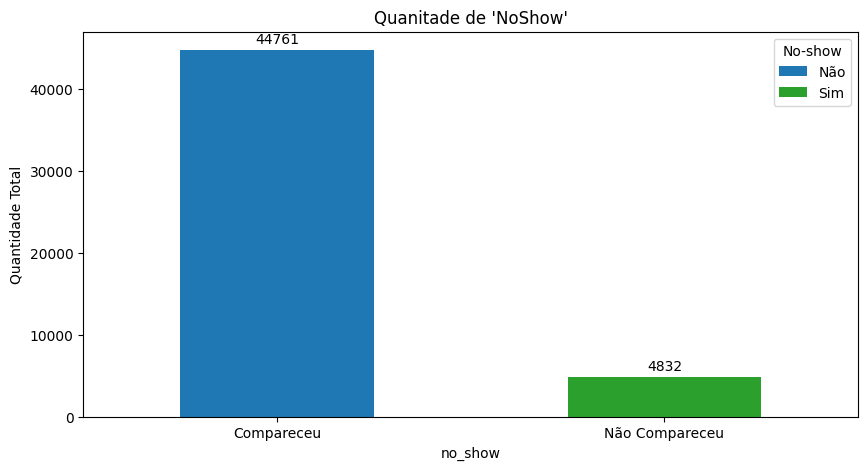

In [175]:
ax = data.no_show.value_counts().plot(
    kind="bar", figsize=(10, 5), color=["C0", "C2"], legend=True, rot=0
)
plt.title("Quanitade de 'NoShow'")
plt.ylabel("Quantidade Total")
ax = plt.gca()
handles = ax.patches[:2]
labels = ["Não", "Sim"]
ax.legend(handles=handles, labels=labels, title="No-show")
plt.xticks(
    labels=["Compareceu", "Não Compareceu"],
    ticks=[0, 1],
)

ax.bar_label(ax.containers[0], fmt="%d", padding=3)
plt.show()

### Análises Demográficas

- Quantidade de No_Show por gênero

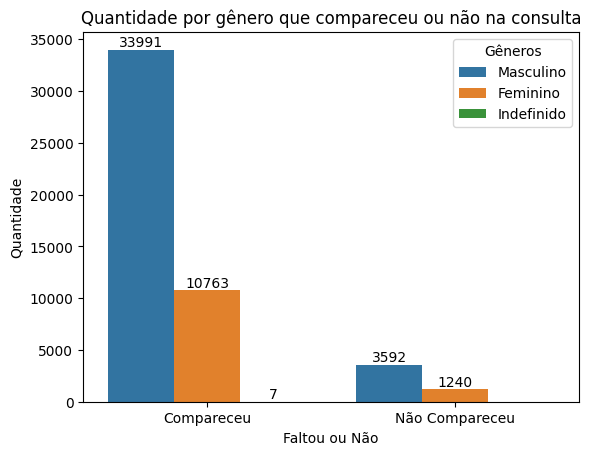

In [176]:
plt.xlabel("Faltou ou Não")
plt.ylabel("Quantidade")
sns.countplot(data=data, x="no_show", hue="gender")
ax = plt.gca()
handles, _ = ax.get_legend_handles_labels()
labels = ["Masculino", "Feminino", "Indefinido"]
ax.legend(handles=handles, labels=labels, title="Gêneros")
plt.xticks(
    labels=["Compareceu", "Não Compareceu"],
    ticks=[0, 1],
)
plt.title("Quantidade por gênero que compareceu ou não na consulta")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()

- Taxa de No-Show por Grupo Etário

C:\Users\Linek\AppData\Local\Temp\ipykernel_19668\1152150665.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("age_group")["no_show"]


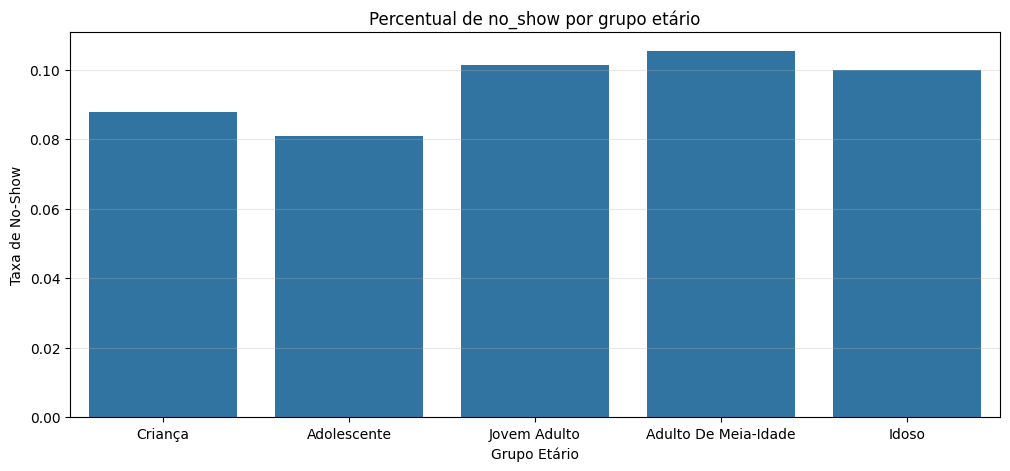

In [177]:
age_rate = (
    data.groupby("age_group")["no_show"]
    .mean()
    .reset_index(name="rate")
    .sort_values("rate", ascending=False)
)
plt.figure(figsize=(12, 5))

ax1 = sns.barplot(
    data=age_rate,
    x="age_group",
    y="rate",
)
plt.title("Percentual de no_show por grupo etário")
plt.xlabel("Grupo Etário")
plt.ylabel("Taxa de No-Show")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [178]:
age_volume = data.groupby("age_group").size().reset_index(name="total")

age_summary = age_rate.merge(age_volume, on="age_group")

C:\Users\Linek\AppData\Local\Temp\ipykernel_19668\1588376246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_volume = data.groupby("age_group").size().reset_index(name="total")


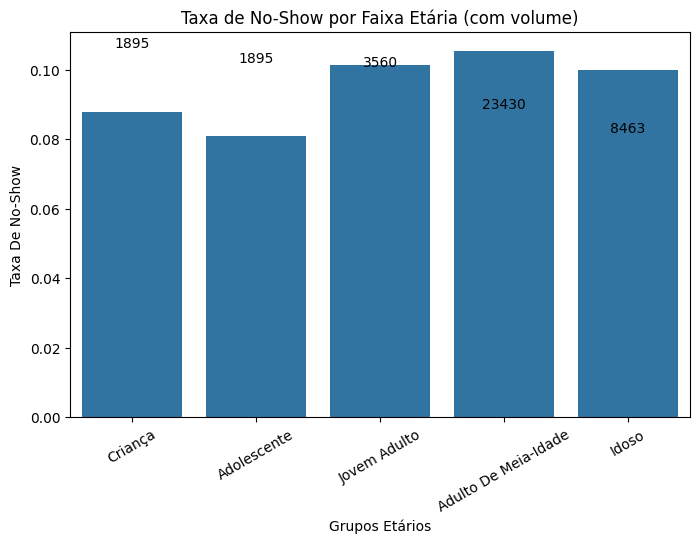

In [179]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=age_summary, x="age_group", y="rate")

for i, row in age_summary.iterrows():
    ax.text(i, row["rate"], f'{row["total"]}', ha="center", va="bottom")

plt.title("Taxa de No-Show por Faixa Etária (com volume)")
plt.xticks(rotation=30)
plt.xlabel("Grupos Etários")
plt.ylabel("Taxa De No-Show")
plt.show()

### Análises Temporais

- Sazonalidade no_show durante os meses do ano

C:\Users\Linek\AppData\Local\Temp\ipykernel_19668\427243241.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")


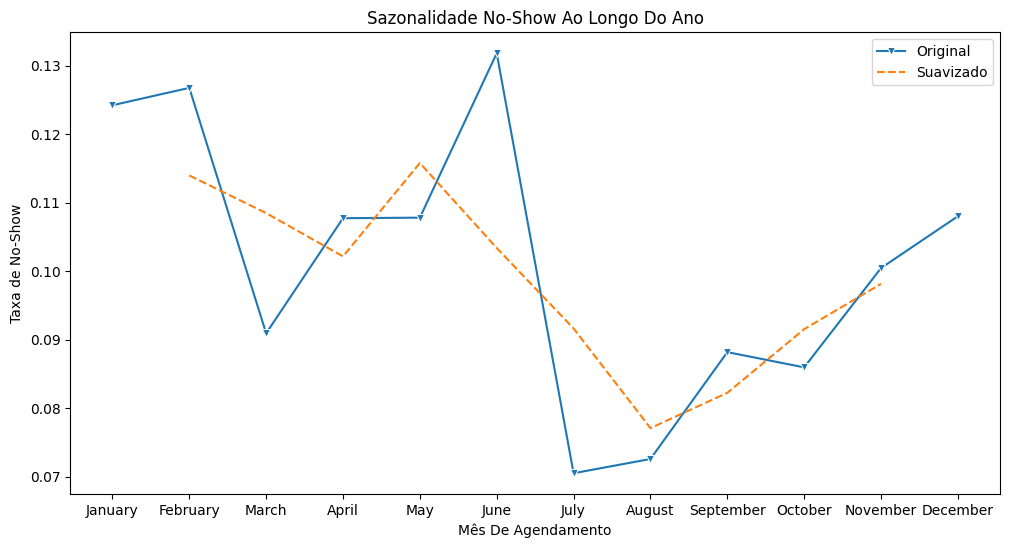

In [201]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

data["appointment_month"] = pd.Categorical(
    data["appointment_month"], categories=month_order, ordered=True
)
monthly_rate = (
    data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")
)
monthly_rate["smooth"] = monthly_rate["rate"].rolling(3, center=True).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_rate, x="appointment_month", y="rate", marker="v", label="Original"
)
sns.lineplot(
    data=monthly_rate,
    x="appointment_month",
    y="smooth",
    linestyle="--",
    label="Suavizado",
)
plt.ylabel("Taxa de No-Show")
plt.xlabel("Mês De Agendamento")
plt.title("Sazonalidade No-Show Ao Longo Do Ano")
plt.show()

### Análises Médicas

In [202]:
data

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,entry_service_date,city,icd,...,rainy_day_before,rain_intensity,heat_intensity,icd_description,disability_intellectual,disability_motor,appointment_shift_morning,age_group,Intervalo de Idade,day_of_the_week
0,physiotherapy,13:20,M,2021-09-09,1,surto,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
1,psychotherapy,13:20,M,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
2,speech therapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
3,physiotherapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,NaN,...,1,no_rain,mild,NaN,0,0,0,NaN,NaN,Thursday
4,physiotherapy,14:00,M,2021-09-09,0,NaN,motor,2020-02-05,B. CAMBORIU,I67,...,1,no_rain,mild,Other cerebrovascular diseases,0,1,0,Idoso,60+ Anos,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,NaN,10:20,M,2022-02-01,1,pai tem médico,intellectual,2019-11-05,ITAJAÍ,F84.5,...,0,no_rain,heavy_cold,Asperger syndrome,1,0,1,Adolescente,13 a 19 Anos,Tuesday
49589,NaN,10:20,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,no_rain,heavy_cold,NaN,0,0,1,NaN,NaN,Tuesday
49590,NaN,11:00,M,2022-02-01,0,NaN,intellectual,2020-02-11,BOMBINHAS,F84,...,0,no_rain,heavy_cold,Pervasive developmental disorders,1,0,1,Criança,0 a 12 Anos,Tuesday
49591,psychotherapy,11:00,M,2022-02-01,1,NaN,NaN,NaN,NaN,NaN,...,0,no_rain,heavy_cold,NaN,0,0,1,NaN,NaN,Tuesday


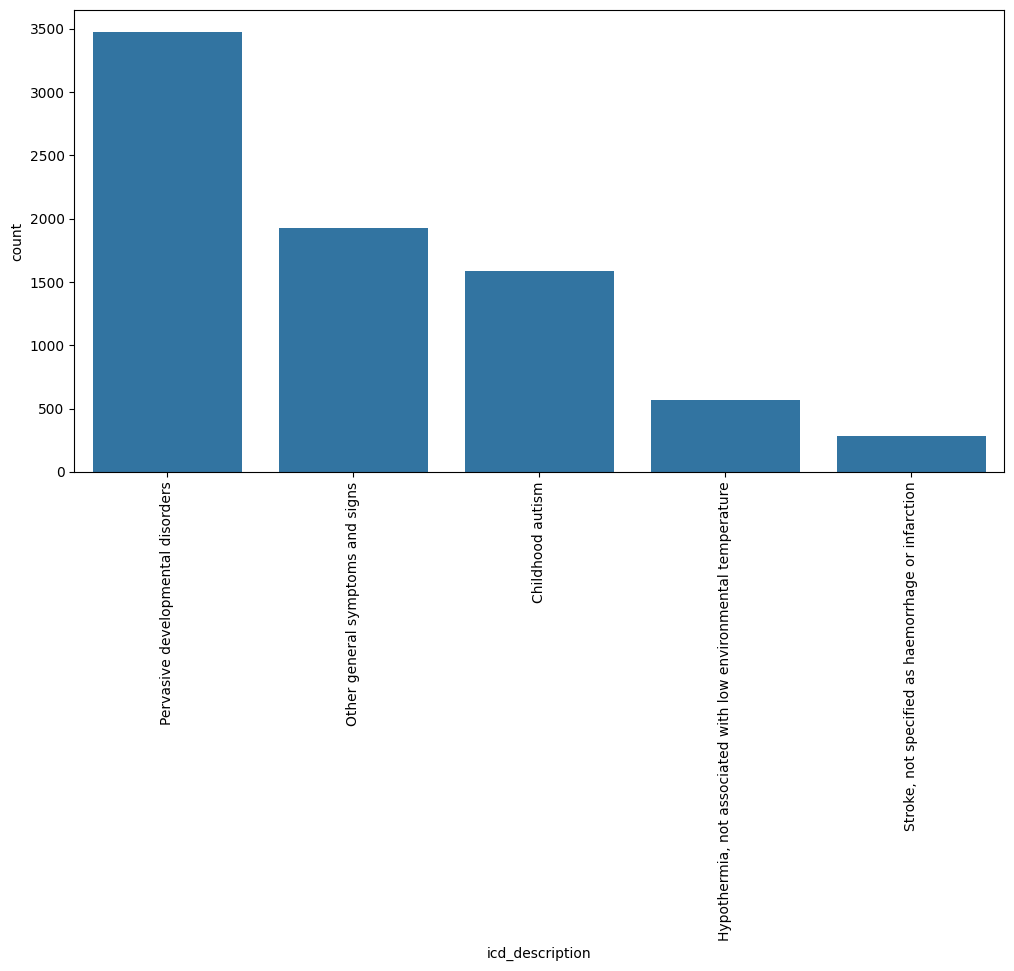

In [209]:
df = data[data["icd_description"].notna()]

top5 = df["icd_description"].value_counts().head(5).index

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x="icd_description", order=top5)
plt.xticks(rotation=90)
plt.show()